In [ ]:
import numpy as np
import copy

def simulate(A, omega, gamma, time, phi=0.0, sigma=0.2, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    signal = A * np.exp(-gamma * time) * np.cos(omega * time + phi)
    noise = rng.normal(0, sigma, size=time.shape)

    return signal + noise

def prior(N, prior_low, prior_high):
    A = np.random.uniform(prior_low[0], prior_high[0], size=N)
    omega = np.random.uniform(prior_low[1], prior_high[1], size=N)
    gamma = np.random.uniform(prior_low[2], prior_high[2], size=N)

    theta = np.stack([A, omega, gamma], axis=1)
    return theta

In [2]:
T_MAX = 10.0                             # seconds, total observation window
FS = 50.0                                # Hz, sampling rate
TIME = np.arange(0.0, T_MAX, 1.0 / FS)   # shape (n_samples,)
sigma = 0.2
labels = [r"$A$", r"$\omega$", r"$\gamma$"]

prior_low_np = np.array([0.5, 1.0, 0.05])
prior_high_np = np.array([5.0, 10.0, 1.0])

N = 1000000
theta_np = prior(N, prior_low_np, prior_high_np)

rng = np.random.default_rng(42)
x_np = np.stack([simulate(*th, time=TIME, sigma=sigma, rng=rng) for th in theta_np])

In [3]:
import torch

theta = torch.tensor(theta_np, dtype=torch.float32)
x = torch.tensor(x_np, dtype=torch.float32)

device = "mps"
device = "cuda" if torch.cuda.is_available() else "cpu"

prior_low = torch.tensor(prior_low_np, dtype=torch.float32)
prior_high = torch.tensor(prior_high_np, dtype=torch.float32)

In [4]:
from nflows.flows import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform
from nflows.transforms.permutations import RandomPermutation

features = 3
context_features = len(TIME)

transforms = []
for _ in range(5):
    transforms.append(
        MaskedAffineAutoregressiveTransform(
            features=3,
            hidden_features=128,
            context_features=context_features,
            num_blocks=3,
            dropout_probability=0.1,
        )
    )
    transforms.append(RandomPermutation(features=features))
    
base = StandardNormal([features])
transform = CompositeTransform(transforms)
flow = Flow(transform, base)

In [5]:
from torch.utils.data import TensorDataset, DataLoader, random_split

# Normalize Prior Samples
theta_normalized = (theta - prior_low) / (prior_high - prior_low)

# Split indices first (on raw, unnormalized x) so val stays untouched by train stats
generator_torch = torch.Generator().manual_seed(42)
n_val = int(0.1 * len(x))
n_train = len(x) - n_val
train_idx, val_idx = random_split(range(len(x)), [n_train, n_val], generator=generator_torch)

# Compute normalization stats from the training split only
x_mean = x[train_idx.indices].mean(axis=0)
x_std = x[train_idx.indices].std(axis=0)

# Apply the same (train-derived) stats to both splits
x_normalized = (x - x_mean) / x_std

dataset = TensorDataset(theta_normalized, x_normalized)
train_set = torch.utils.data.Subset(dataset, train_idx.indices)
val_set = torch.utils.data.Subset(dataset, val_idx.indices)

batch_size = 1024

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=4)

In [28]:
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4, weight_decay=1e-3)

num_epochs = 200

train_loss_history = []
val_loss_history = []

import os
experiment_name = "weight_decay_1e-3"
checkpoint_dir = f"checkpoints/{experiment_name}"
os.makedirs(checkpoint_dir, exist_ok=True)

best_epoch = -1
best_state = None
best_val_loss = float("inf")

flow = flow.to(device)

for epoch in range(num_epochs):
    flow.train()
    train_losses = []

    for theta_batch, x_batch in train_loader:
        optimizer.zero_grad()
        loss = -flow.log_prob(inputs=theta_batch.to(device), context=x_batch.to(device)).mean()
        loss.backward()
        optimizer.step()    
        train_losses.append(loss.item())
        #train_losses.append(loss.item().detach().cpu())

    flow.eval()
    val_losses = []
    with torch.no_grad():
        for theta_val, x_val in val_loader:
            loss = -flow.log_prob(inputs=theta_val.to(device), context=x_val.to(device)).mean()
            val_losses.append(loss.item())
            #val_losses.append(loss.item().detach().cpu())

    train_epoch_loss = np.mean(train_losses)
    val_epoch_loss = np.mean(val_losses)
    train_loss_history.append(train_epoch_loss)
    val_loss_history.append(val_epoch_loss)

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        best_epoch = epoch
        best_state = copy.deepcopy(flow.state_dict())

        # Save best checkpoint to disk whenever val loss improves
        torch.save({
            "epoch": epoch,
            "model_state_dict": flow.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_epoch_loss,
        }, os.path.join(checkpoint_dir, "flow_best.pt"))


    # Also save the latest state every epoch, so a crash never loses more than 1 epoch
    torch.save({
        "epoch": epoch,
        "model_state_dict": flow.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_loss": val_epoch_loss,
        "train_loss_history": train_loss_history,
        "val_loss_history": val_loss_history,
    }, os.path.join(checkpoint_dir, "flow_latest.pt"))

    if epoch % 5 == 0:
        print(f"epoch {epoch}: train {train_epoch_loss:.4f}  val {val_epoch_loss:.4f}")

final_state = copy.deepcopy(flow.state_dict())
print(f"Best epoch: {best_epoch} with validation loss: {best_val_loss:.4f}")

epoch 0: train -11.0078  val -10.7749
epoch 5: train -11.0470  val -10.7601
epoch 10: train -11.0790  val -10.8445
epoch 15: train -11.1051  val -10.8241
epoch 20: train -11.1268  val -10.8639
epoch 25: train -11.1565  val -10.8190
epoch 30: train -11.1802  val -10.8316
epoch 35: train -11.2042  val -10.7996
epoch 40: train -11.2262  val -10.7194
epoch 45: train -11.2447  val -10.8001
epoch 50: train -11.2663  val -10.8212
epoch 55: train -11.2861  val -10.7635
epoch 60: train -11.3052  val -10.8038
epoch 65: train -11.3235  val -10.7922
epoch 70: train -11.3423  val -10.7004
epoch 75: train -11.3584  val -10.7337
epoch 80: train -11.3725  val -10.6626
epoch 85: train -11.3849  val -10.5951
epoch 90: train -11.4009  val -10.6664
epoch 95: train -11.4171  val -10.6793
epoch 100: train -11.4298  val -10.7102
epoch 105: train -11.4414  val -10.6497
epoch 110: train -11.4566  val -10.6427
epoch 115: train -11.4665  val -10.6547
epoch 120: train -11.4780  val -10.6406
epoch 125: train -11.4

In [47]:
print(f"Best epoch: {best_epoch} with validation loss: {best_val_loss:.4f}")

Best epoch: 11 with validation loss: -10.8784


In [8]:
#checkpoint = torch.load("checkpoints/flow_best.pt", weights_only=True)
#flow.load_state_dict(checkpoint["model_state_dict"])
#flow.eval()

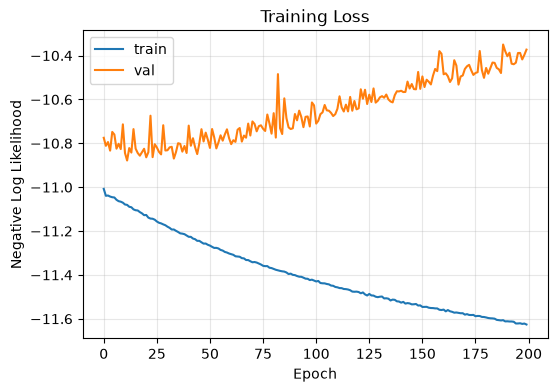

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(train_loss_history, label="train")
plt.plot(val_loss_history, label="val")
plt.xlabel("Epoch")
plt.ylabel("Negative Log Likelihood")
plt.title("Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

$A$: true=3.891  posterior mean=3.914  std=0.047
$\omega$: true=3.975  posterior mean=3.975  std=0.006
$\gamma$: true=0.292  posterior mean=0.299  std=0.006


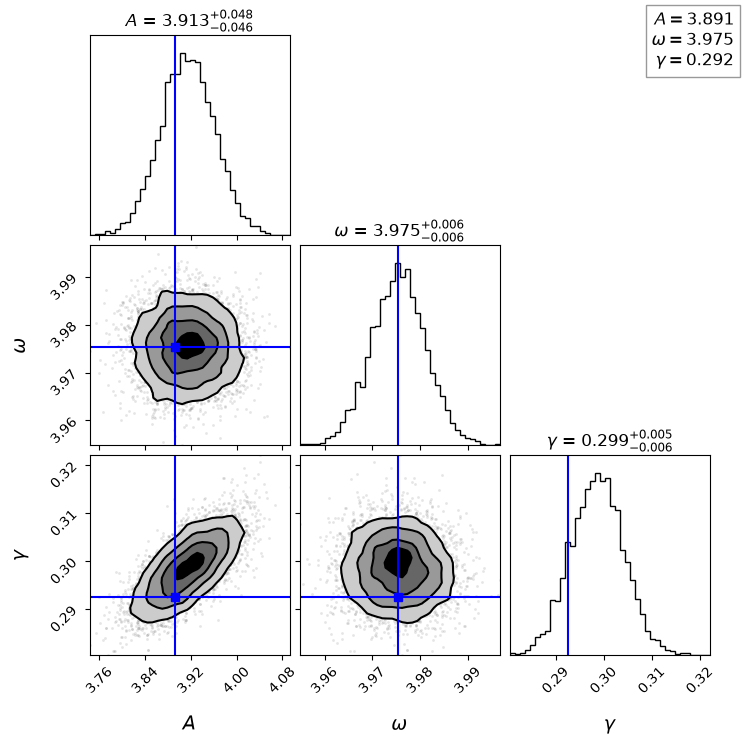

In [33]:
obs_parameters = prior(1, prior_low_np, prior_high_np)[0]
x_obs = simulate(*obs_parameters, time=TIME, sigma=sigma, rng=rng)
x_obs = torch.tensor(x_obs, dtype=torch.float32).unsqueeze(0)
x_obs = (x_obs - x_mean) / x_std

flow.load_state_dict(best_state)
flow.eval()

with torch.no_grad():
    samples_u = flow.sample(5000, context=x_obs)   # sample in the unconstrained space

# Map back into the original prior range
def to_constrained(samples_u):
    samples = samples_u * (prior_high - prior_low) + prior_low
    return samples

samples = to_constrained(samples_u)
samples = samples.squeeze(0)
samples = samples.detach().cpu().numpy()

for i, name in enumerate(labels):
        mean = samples[:, i].mean()
        std = samples[:, i].std()
        print(f"{name}: true={obs_parameters[i]:.3f}  posterior mean={mean:.3f}  std={std:.3f}")

import matplotlib.pyplot as plt
import corner

figure = corner.corner(
    samples,
    labels=[r"$A$", r"$\omega$", r"$\gamma$"],
    truths=obs_parameters,
    truth_color="blue",
    show_titles=True,
    title_fmt=".3f", 
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    bins=40,
    smooth=1.0,
    fill_contours=True,
    #range=[
    #    [prior_low[0], prior_high[0]],
    #    [prior_low[1], prior_high[1]],
    #    [prior_low[2], prior_high[2]],
    #]
)

truth_text = (
    rf"$A = {obs_parameters[0]:.3f}$" "\n"
    rf"$\omega = {obs_parameters[1]:.3f}$" "\n"
    rf"$\gamma = {obs_parameters[2]:.3f}$"
)

figure.text(
    0.98, 0.98,
    truth_text,
    ha="right",
    va="top",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

$A$: Mean Percentage Error = 0.1036 %, Std Dev of Error = 3.0578 %
$\omega$: Mean Percentage Error = 0.0032 %, Std Dev of Error = 0.6976 %
$\gamma$: Mean Percentage Error = -0.1781 %, Std Dev of Error = 5.0977 %


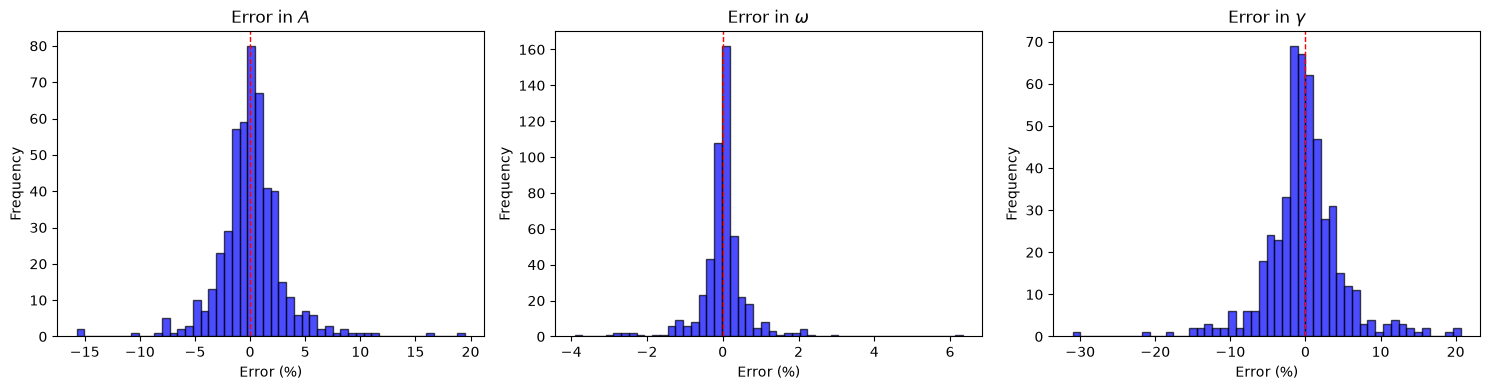

In [45]:
errors = []
for i in range(500):

    theta_true =  prior(1, prior_low_np, prior_high_np)[0]

    x_obs = simulate(*theta_true, time=TIME, sigma=sigma, rng=rng)
    x_obs = torch.tensor(x_obs, dtype=torch.float32).unsqueeze(0)
    x_obs = (x_obs - x_mean) / x_std

    flow.eval()
    with torch.no_grad():
        samples_u = flow.sample(5000, context=x_obs)   # sample in the unconstrained space

    samples = to_constrained(samples_u)
    samples = samples.squeeze(0)
    samples = samples.detach().cpu().numpy()

    mean = samples.mean(0)

    errors.append((mean - theta_true)/theta_true)

# Plot the errors in three subplots
errors = np.array(errors)

# Print the mean and standard deviation of the errors for each parameter
for i, name in enumerate(labels):
    mean_error = np.mean(100 * errors[:, i])
    std_error = np.std(100 * errors[:, i])
    print(f"{name}: Mean Percentage Error = {mean_error:.4f} %, Std Dev of Error = {std_error:.4f} %")

# Plot the errors in three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.hist(100 * errors[:, i], bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax.axvline(0, color='red', linestyle='dashed', linewidth=1)
    ax.set_title(f"Error in {labels[i]}")
    ax.set_xlabel("Error (%)")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


# Comparision with MCMC

In [36]:
def add_comparison_table(fig, labels, true_theta, mcmc_samples, nn_samples,
                          bbox=(0.55, 0.55, 0.4, 0.4)):
    """
    Add a table comparing true values, MCMC posterior (mean +- std), and
    NN/flow posterior (mean +- std) into the empty upper-right region of a
    corner.corner figure.

    Parameters
    ----------
    fig : matplotlib Figure
        The figure returned by corner.corner(...).
    labels : list of str
        Parameter labels, e.g. [r"$A$", r"$\omega$", r"$\gamma$"].
    true_theta : array-like, shape (n_params,)
        True parameter values.
    mcmc_samples, nn_samples : array-like, shape (n_samples, n_params)
        Posterior samples from each method.
    bbox : (left, bottom, width, height)
        Position of the table axes in figure-relative (0-1) coordinates.
        Defaults roughly to the empty upper-right corner; nudge if it
        overlaps the corner plot panels or the figure title.

    Returns
    -------
    ax : the new axes the table was drawn on
    """
    mcmc_mean, mcmc_std = mcmc_samples.mean(axis=0), mcmc_samples.std(axis=0)
    nn_mean, nn_std = nn_samples.mean(axis=0), nn_samples.std(axis=0)

    col_labels = ["Param", "True", "MCMC", "NN"]
    cell_text = [
        [
            labels[i],
            f"{true_theta[i]:.3f}",
            f"{mcmc_mean[i]:.3f} ± {mcmc_std[i]:.3f}",
            f"{nn_mean[i]:.3f} ± {nn_std[i]:.3f}",
        ]
        for i in range(len(labels))
    ]

    ax = fig.add_axes(bbox)
    ax.axis("off")
    table = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.8)
    return ax

<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
/var/folders/b8/rdglk9j13q9gpzqh2phffrgm0008nc/T/ipykernel_31496/4085738511.py:13: SyntaxWarning: invalid escape sequence '\o'
  Parameter labels, e.g. [r"$A$", r"$\omega$", r"$\gamma$"].


In [37]:
x_obs_mcmc_np = np.load("../MCMC/x_obs.npy")
mcmc_samples = np.load("../MCMC/mcmc_emcee_posterior_samples.npy")
mcmc_theta_true = np.load("../MCMC/true_theta.npy")
burnin = np.load("../MCMC/burnin.npy")
thin = np.load("../MCMC/thin.npy")

In [38]:
# flatten the MCMC samples to have shape (n_samples, n_parameters) and remove the burn-in samples and apply thinning
mcmc_samples_flattened = mcmc_samples[burnin::thin].reshape(-1, mcmc_samples.shape[-1])

x_obs_mcmc = torch.tensor(x_obs_mcmc_np, dtype=torch.float32).unsqueeze(0)
x_obs_mcmc = (x_obs_mcmc - x_mean) / x_std

flow.eval()
with torch.no_grad():
    samples_u = flow.sample(mcmc_samples_flattened.shape[0], context=x_obs_mcmc)
nn_samples = to_constrained(samples_u).squeeze(0).detach().cpu().numpy()

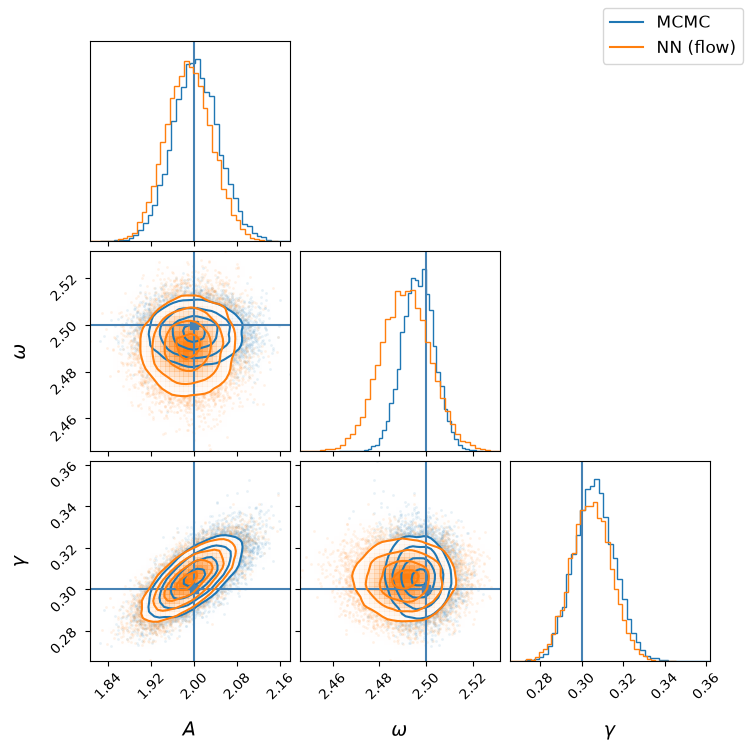

In [39]:
fig = corner.corner(
    mcmc_samples_flattened, 
    labels=labels, 
    truths=mcmc_theta_true,
    color="C0", 
    show_titles=False,
    label_kwargs={"fontsize": 14},
    bins=40,
    smooth=1.0,
)

corner.corner(
    nn_samples, 
    fig=fig, 
    color="C1", 
    show_titles=False,
    bins=40,
    smooth=1.0,
    )

import matplotlib.lines as mlines
fig.legend(
    handles=[
        mlines.Line2D([], [], color="C0", label="MCMC"),
        mlines.Line2D([], [], color="C1", label="NN (flow)"),
    ],
    loc="upper right",
    fontsize=12
)

plt.show()

## Importance Sampling

In [40]:
def log_likelihood_gaussian(theta, x_obs_raw, time, sigma, phi=0.0):
    """theta: (n_samples, 3) array [A, omega, gamma]; x_obs_raw: (n_time,) unnormalized."""
    A, omega, gamma = theta[:, 0:1], theta[:, 1:2], theta[:, 2:3]
    signal = A * np.exp(-gamma * time[None, :]) * np.cos(omega * time[None, :] + phi)
    resid = x_obs_raw[None, :] - signal
    n_time = time.shape[0]
    return -0.5 * np.sum((resid / sigma) ** 2, axis=1) - n_time * np.log(sigma * np.sqrt(2 * np.pi))


def importance_sample(flow, x_obs_norm, x_obs_raw, time, sigma, prior_low, prior_high,
                       n_proposal=20000, n_resample=5000):
    """
    Reweight flow proposal samples against the true likelihood via self-normalized IS.
    x_obs_norm: (1, n_time) normalized context for the flow.
    x_obs_raw:  (n_time,) raw unnormalized observation, for the likelihood.
    """
    flow.eval()
    with torch.no_grad():
        samples_u, log_q = flow.sample_and_log_prob(n_proposal, context=x_obs_norm)
    samples_u = samples_u.squeeze(0)
    log_q = log_q.squeeze(0)

    theta = samples_u * (prior_high - prior_low) + prior_low
    theta_np = theta.detach().cpu().numpy()
    log_q_np = log_q.detach().cpu().numpy()

    log_lik = log_likelihood_gaussian(theta_np, x_obs_raw, time, sigma)

    in_bounds = np.all(
        (theta_np >= prior_low.numpy()) & (theta_np <= prior_high.numpy()), axis=1
    )

    # prior density (uniform) and the theta<->theta_normalized Jacobian are both
    # constant across samples and cancel under self-normalization
    log_w = log_lik - log_q_np
    log_w[~in_bounds] = -np.inf
    log_w -= np.max(log_w[np.isfinite(log_w)])
    w = np.exp(log_w)
    w /= w.sum()

    ess = 1.0 / np.sum(w ** 2)
    resample_idx = np.random.choice(len(theta_np), size=n_resample, replace=True, p=w)

    return {"theta_proposal": theta_np, "weights": w, "ess": ess,
            "theta_resampled": theta_np[resample_idx]}

In [88]:
x_obs_raw_is = copy.deepcopy(x_obs_mcmc_np)  # raw, no normalization
x_obs_norm_is = torch.tensor(x_obs_raw_is, dtype=torch.float32).unsqueeze(0)

In [89]:
x_obs_mcmc.shape, x_obs_norm_is.shape, x_obs_raw_is.shape

(torch.Size([1, 500]), torch.Size([1, 500]), (500,))

In [90]:
x_obs_norm_is = (x_obs_norm_is - x_mean) / x_std

result_is = importance_sample(flow, x_obs_norm_is, x_obs_raw_is, TIME, sigma,
                            prior_low, prior_high, n_proposal=20000, n_resample=5000)

print(f"ESS: {result_is['ess']:.1f} / 20000")
is_samples = result_is["theta_resampled"]
for i, name in enumerate(labels):
    print(f"{name}: IS mean={is_samples[:,i].mean():.3f}  std={is_samples[:,i].std():.3f}")

ESS: 12598.7 / 20000
$A$: IS mean=2.002  std=0.043
$\omega$: IS mean=2.497  std=0.007
$\gamma$: IS mean=0.306  std=0.010


In [92]:
print(f"Importance Sampling Efficiency: {result_is['ess']*100 / 20000:.1f}%")

Importance Sampling Efficiency: 63.0%


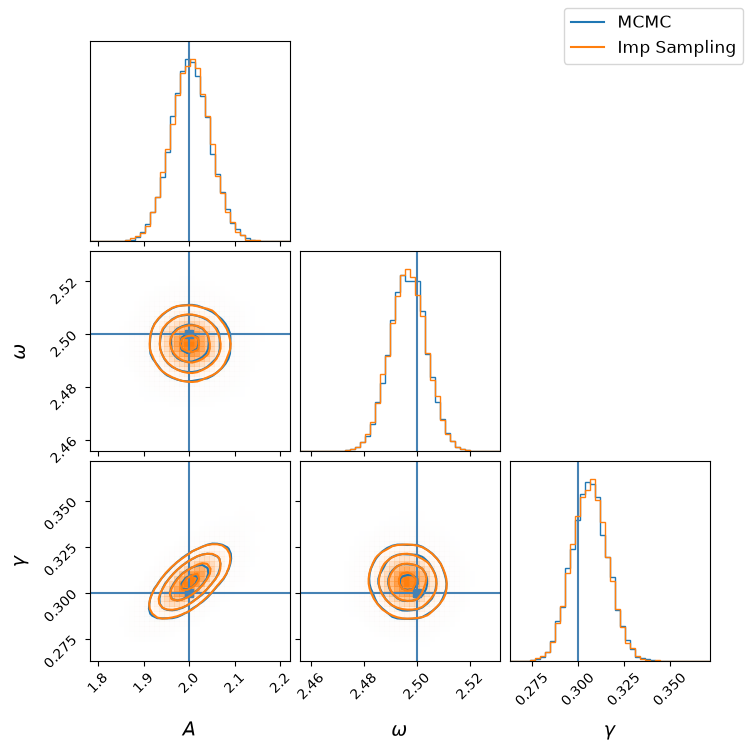

In [107]:
plot_range = [
    (mcmc_samples_flattened[:, i].min() - 1*mcmc_samples_flattened[:, i].std(),
     mcmc_samples_flattened[:, i].max() + 1*mcmc_samples_flattened[:, i].std())
    for i in range(mcmc_samples_flattened.shape[1])
]

fig_is = corner.corner(
    mcmc_samples_flattened, 
    labels=labels, 
    truths=mcmc_theta_true,
    color="C0", 
    show_titles=False,
    label_kwargs={"fontsize": 14},
    bins=40,
    smooth=1.0,
    hist_kwargs={"density": True},
    plot_datapoints=False,
    range=plot_range
)
corner.corner(
    result_is["theta_proposal"], 
    weights=result_is["weights"],
    fig=fig_is, 
    color="C1", 
    show_titles=False,
    bins=40,
    smooth=1.0,
    plot_datapoints=False,
    hist_kwargs={"density": True},
    range=plot_range
)


import matplotlib.lines as mlines
fig_is.legend(
    handles=[
        mlines.Line2D([], [], color="C0", label="MCMC"),
        mlines.Line2D([], [], color="C1", label="Imp Sampling"),
    ],
    loc="upper right",
    fontsize=12
)

plt.show()

# Check for random sample drawn from prior

In [93]:
from IPython.display import display, Math

def print_theta(theta):
    labels_print = [r"A", r"\omega", r"\gamma"]
    expr = r"\\ ".join(
        f"{label} = {value:.4f}"
        for label, value in zip(labels_print, theta)
    )
    display(Math(r"\begin{aligned}" + expr + r"\end{aligned}"))

In [78]:
import mcmc

new_theta = prior(1, prior_low_np, prior_high_np)[0]
print_theta(new_theta)

new_x_obs_mcmc_np, new_mcmc_samples, new_burn, new_thin = mcmc.main(true_theta=new_theta,)

<IPython.core.display.Math object>

100%|██████████| 50000/50000 [00:06<00:00, 8240.27it/s]


Autocorrelation time per parameter: {'$A$': np.float64(56.3), '$\\omega$': np.float64(21.5), '$\\gamma$': np.float64(54.8)}
n_steps=50000
burn=112
thin=28
$A$: true=1.922  posterior mean=1.871  std=0.058
$\omega$: true=5.880  posterior mean=5.875  std=0.017
$\gamma$: true=0.545  posterior mean=0.535  std=0.024


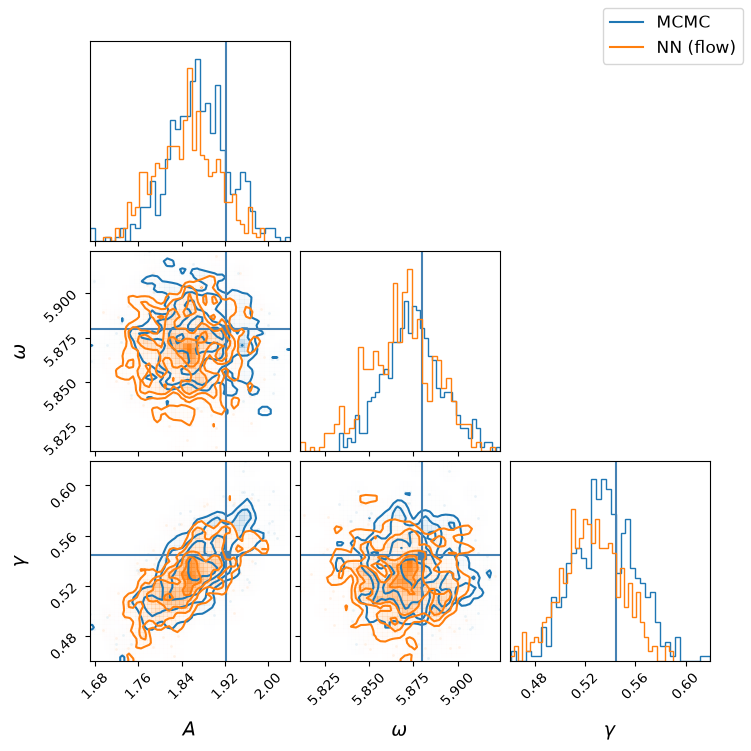

In [104]:
# flatten the MCMC samples to have shape (n_samples, n_parameters) and remove the burn-in samples and apply thinning
new_mcmc_samples_flattened = new_mcmc_samples[new_burn::new_thin].reshape(-1, new_mcmc_samples.shape[-1])

new_x_obs_mcmc = torch.tensor(new_x_obs_mcmc_np, dtype=torch.float32).unsqueeze(0)
new_x_obs_mcmc = (new_x_obs_mcmc - x_mean) / x_std

flow.eval()
with torch.no_grad():
    new_samples_u = flow.sample(new_mcmc_samples_flattened.shape[0], context=new_x_obs_mcmc)
new_nn_samples = to_constrained(new_samples_u).squeeze(0).detach().cpu().numpy()

new_fig = corner.corner(
    new_mcmc_samples_flattened, 
    labels=labels, 
    truths=new_theta,
    color="C0", 
    show_titles=False,
    label_kwargs={"fontsize": 14},
    bins=40,
    smooth=1.0,
)

corner.corner(
    new_nn_samples, 
    fig=new_fig, 
    color="C1", 
    show_titles=False,
    bins=40,
    smooth=1.0,
    )

import matplotlib.lines as mlines
new_fig.legend(
    handles=[
        mlines.Line2D([], [], color="C0", label="MCMC"),
        mlines.Line2D([], [], color="C1", label="NN (flow)"),
    ],
    loc="upper right",
    fontsize=12
)

plt.show()

Importance Sampling Efficiency: 74.1%


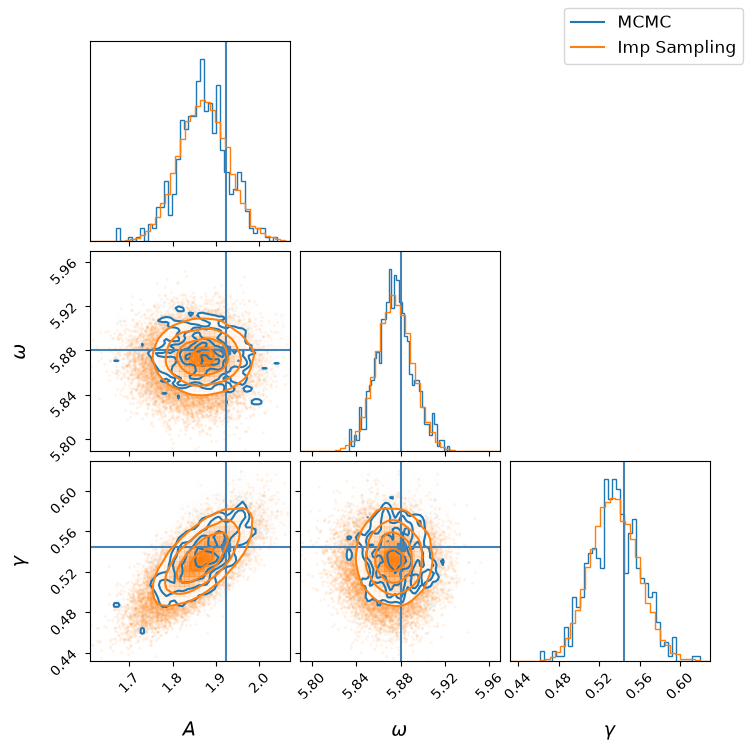

In [109]:
new_result_is = importance_sample(flow, new_x_obs_mcmc, new_x_obs_mcmc_np, TIME, sigma,
                            prior_low, prior_high, n_proposal=20000, n_resample=5000)

new_is_samples = new_result_is["theta_resampled"]

print(f"Importance Sampling Efficiency: {new_result_is['ess']*100 / 20000:.1f}%")


new_plot_range = [
    (new_mcmc_samples_flattened[:, i].min() - 1*new_mcmc_samples_flattened[:, i].std(),
     new_mcmc_samples_flattened[:, i].max() + 1*new_mcmc_samples_flattened[:, i].std())
    for i in range(new_mcmc_samples_flattened.shape[1])
]

new_fig_is = corner.corner(
    new_mcmc_samples_flattened, 
    labels=labels, 
    truths=new_theta,
    color="C0", 
    show_titles=False,
    label_kwargs={"fontsize": 14},
    bins=40,
    smooth=1.0,
    hist_kwargs={"density": True},
    plot_datapoints=True,
    #range=new_plot_range
)
corner.corner(
    new_result_is["theta_proposal"], 
    weights=new_result_is["weights"],
    fig=new_fig_is, 
    color="C1", 
    show_titles=False,
    bins=40,
    smooth=1.0,
    plot_datapoints=True,
    hist_kwargs={"density": True},
    #range=new_plot_range
)

import matplotlib.lines as mlines
new_fig_is.legend(
    handles=[
        mlines.Line2D([], [], color="C0", label="MCMC"),
        mlines.Line2D([], [], color="C1", label="Imp Sampling"),
    ],
    loc="upper right",
    fontsize=12
)
plt.show()